# Problem Solving

An agent solves a problem by *searching*: it starts in an initial state and looks for a sequence of
actions that leads to a goal state.

## The tree as a dictionary

Each key is a state and its value is the list of states we can reach from it.

In [1]:
## the state space: state -> states reachable from it
tree = {
    "A": ["B", "C"],
    "B": ["D", "E"],
    "C": ["F"],
    "D": [],
    "E": [],
    "F": [],
}

tree

{'A': ['B', 'C'], 'B': ['D', 'E'], 'C': ['F'], 'D': [], 'E': [], 'F': []}

In [2]:
## the actions available in a state
tree["A"]

['B', 'C']

In [3]:
## a leaf has no actions available
tree["F"]

[]

## Visualizing the tree

`networkx` turns the dictionary into a graph and `matplotlib` draws it.

In [4]:
#!pip install networkx

In [6]:
import networkx as nx
import matplotlib.pyplot as plt

In [7]:
## build the graph from the dictionary
graph = nx.Graph()
for parent, children in tree.items():
    graph.add_node(parent)

    for child in children:
        graph.add_edge(parent, child)

graph.edges()

EdgeView([('A', 'B'), ('A', 'C'), ('B', 'D'), ('B', 'E'), ('C', 'F')])

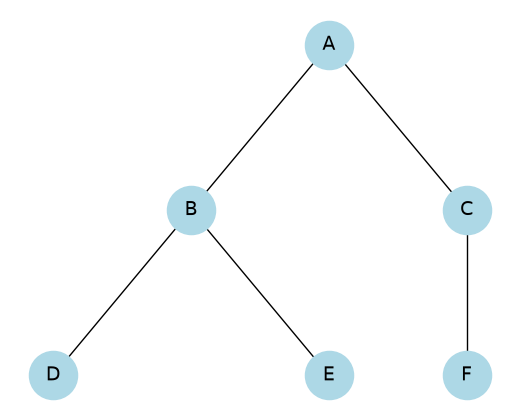

In [8]:
## fixed coordinates so the graph looks like a tree
positions = {
    "A": (2, 2),
    "B": (1, 1),
    "C": (3, 1),
    "D": (0, 0),
    "E": (2, 0),
    "F": (3, 0),
}

plt.figure(figsize=(5, 4))
nx.draw(graph, positions, with_labels=True, node_size=1200, node_color="lightblue", font_size=14)
plt.show()

# Search algorithm

> * Start with a frontier that contains the initial state
> * Repeat
>     * If the frontier is empty, then no solution
>     * Remove a node from the frontier
>     * If node contains goal state, return the solution
>     * Expand node, add resulting nodes to the frontier

The **frontier** is the list of states already generated but not explored yet.

### Step by step

We go from `A` to `E`. Before writing the loop, let's do a few iterations by hand.

In [13]:
start = "A"
goal = "E"

## start with a frontier that contains the initial state
frontier = [start]
frontier

['A']

In [14]:
## remove a node from the frontier (we take the first one)
current = frontier.pop(0)

print("current :", current)
print("is goal :", current == goal)
print("frontier:", frontier)

current : A
is goal : False
frontier: []


In [15]:
## expand the node: add the resulting states to the frontier
frontier = frontier + tree[current]
frontier

['B', 'C']

In [16]:
## second iteration
current = frontier.pop(0)

print("current :", current)
print("is goal :", current == goal)
print("frontier:", frontier)

## expand the node: add the resulting states to the frontier
frontier = frontier + tree[current]

current : B
is goal : False
frontier: ['C']


### Loop

The algorithm simply repeats these steps until the frontier is empty

In [17]:
start = "A"
goal = "F"

## start with a frontier that contains the initial state
frontier = [start]
step = 0

## repeat
while True:

    ## if the frontier is empty, then no solution
    if not frontier:
        print("no solution")
        break

    ## remove a node from the frontier
    current = frontier.pop(0)
    step = step + 1
    print(f"{step}. remove {current} -> frontier: {frontier}")

    ## if node contains goal state, return the solution
    if current == goal:
        print(f"\nGoal {goal} found after {step} steps")
        break

    ## expand node, add resulting nodes to the frontier
    frontier = frontier + tree[current]
    print(f"   expand {current} -> frontier: {frontier}")

1. remove A -> frontier: []
   expand A -> frontier: ['B', 'C']
2. remove B -> frontier: ['C']
   expand B -> frontier: ['C', 'D', 'E']
3. remove C -> frontier: ['D', 'E']
   expand C -> frontier: ['D', 'E', 'F']
4. remove D -> frontier: ['E', 'F']
   expand D -> frontier: ['E', 'F']
5. remove E -> frontier: ['F']
   expand E -> frontier: ['F']
6. remove F -> frontier: []

Goal F found after 6 steps


# Breadth-First Search (BFS)

## Queue (FIFO)

`append()` adds at the end, `pop(0)` removes from the front: the first one in is the first one out.

In [27]:
queue = []

## three people arrive at the queue
queue.append("A")
print("append A ->", queue)

queue.append("B")
print("append B ->", queue)

queue.append("C")
print("append C ->", queue)

append A -> ['A']
append B -> ['A', 'B']
append C -> ['A', 'B', 'C']


In [28]:
## they are served in the same order they arrived
print("pop(0) ->", queue.pop(0), "| queue:", queue)
print("pop(0) ->", queue.pop(0), "| queue:", queue)
print("pop(0) ->", queue.pop(0), "| queue:", queue)

pop(0) -> A | queue: ['B', 'C']
pop(0) -> B | queue: ['C']
pop(0) -> C | queue: []


## BFS
Frontier as a **queue**: the algorithm explores the tree level by level. Goal: `F`.

In [29]:
start = "A"
goal = "F"

frontier = [start]
parents = {start: None}
visited_order = []

while frontier:

    ## FIFO: remove the first state added
    current = frontier.pop(0)
    visited_order.append(current)
    print(f"remove {current} -> frontier: {frontier}")

    if current == goal:
        break

    for neighbor in tree[current]:
        frontier.append(neighbor)
        parents[neighbor] = current

    print(f"expand {current} -> frontier: {frontier}")

bfs_order = visited_order
print("\nvisited order:", bfs_order)

remove A -> frontier: []
expand A -> frontier: ['B', 'C']
remove B -> frontier: ['C']
expand B -> frontier: ['C', 'D', 'E']
remove C -> frontier: ['D', 'E']
expand C -> frontier: ['D', 'E', 'F']
remove D -> frontier: ['E', 'F']
expand D -> frontier: ['E', 'F']
remove E -> frontier: ['F']
expand E -> frontier: ['F']
remove F -> frontier: []

visited order: ['A', 'B', 'C', 'D', 'E', 'F']


# Depth-First Search (DFS)

## Stack (LIFO)

`append()` adds on top, `pop()` removes from the top: the last one in is the first one out.

In [30]:
stack = []

## three plates are piled up
stack.append("A")
print("append A ->", stack)

stack.append("B")
print("append B ->", stack)

stack.append("C")
print("append C ->", stack)

append A -> ['A']
append B -> ['A', 'B']
append C -> ['A', 'B', 'C']


In [31]:
## the last plate piled up is the first one taken
print("pop() ->", stack.pop(), "| stack:", stack)
print("pop() ->", stack.pop(), "| stack:", stack)
print("pop() ->", stack.pop(), "| stack:", stack)

pop() -> C | stack: ['A', 'B']
pop() -> B | stack: ['A']
pop() -> A | stack: []


## DFS
Same code as BFS: only `pop(0)` becomes `pop()`. Now the search goes as deep as possible before
trying another branch.

In [33]:
start = "A"
goal = "F"

frontier = [start]
parents = {start: None}
visited_order = []

while frontier:
    
    ## LIFO: remove the last state added (the deepest one)
    current = frontier.pop()
    visited_order.append(current)
    print(f"remove {current} -> frontier: {frontier}")

    if current == goal:
        break

    for neighbor in tree[current]:
        frontier.append(neighbor)
        parents[neighbor] = current

    print(f"expand {current} -> frontier: {frontier}")

dfs_order = visited_order
print("\nvisited order:", dfs_order)

remove A -> frontier: []
expand A -> frontier: ['B', 'C']
remove C -> frontier: ['B']
expand C -> frontier: ['B', 'F']
remove F -> frontier: ['B']

visited order: ['A', 'C', 'F']
